# 02 — Baseline Model (Phase A)
Demographic features → LightGBM → Optuna tuning → SHAP explanations

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, brier_score_loss, classification_report
)
from sklearn.calibration import calibration_curve
import joblib
from datetime import date

from src.feature_engineering import get_X_y
from src.config import TRAIN_TEST_DATE, CAT_FEATURES, PHASE_A_FEATURES

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 50)

## 1. Build dataset

In [2]:
training_df = pd.read_parquet('../data/processed/training_dataset.parquet')
X, y = get_X_y(training_df)
print(f"Loaded: {training_df.shape[0]:,} clients — {y.mean():.1%} chronic")

Loaded: 9,576 clients — 34.0% chronic


## 2. Temporal train/test split

In [3]:
train_mask = training_df['Date Client Record Was Created'] < TRAIN_TEST_DATE
test_mask  = training_df['Date Client Record Was Created'] >= TRAIN_TEST_DATE

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {len(X_train):,} clients | Chronic rate: {y_train.mean():.1%}")
print(f"Test:  {len(X_test):,} clients  | Chronic rate: {y_test.mean():.1%}")

Train: 7,227 clients | Chronic rate: 39.3%
Test:  2,349 clients  | Chronic rate: 17.9%


## 3. Hyperparameter tuning with Optuna

In [4]:
# Identify categorical feature indices for LightGBM
cat_cols_in_X = [c for c in CAT_FEATURES if c in X_train.columns]

def objective(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'verbose'          : -1,
        'scale_pos_weight' : (y_train == 0).sum() / (y_train == 1).sum(),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'n_estimators'     : 300,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        categorical_feature=cat_cols_in_X,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best ROC-AUC: 0.7792
Best params: {'num_leaves': 72, 'max_depth': 3, 'learning_rate': 0.048876823175539506, 'colsample_bytree': 0.5508870346496675, 'subsample': 0.5689637628705488, 'min_child_samples': 24}


## 4. Train final model with best params

In [5]:
best_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'verbose'          : -1,
    'scale_pos_weight' : (y_train == 0).sum() / (y_train == 1).sum(),
    'n_estimators'     : 500,
    **study.best_params,
}

model = lgb.LGBMClassifier(**best_params)
model.fit(
    X_train, y_train,
    categorical_feature=cat_cols_in_X,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)
print('Model trained.')

Model trained.


## 5. Evaluation metrics

In [6]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1      = f1_score(y_test, y_pred)
recall  = recall_score(y_test, y_pred)
brier   = brier_score_loss(y_test, y_pred_proba)

print(f"ROC-AUC : {roc_auc:.4f}  (target > 0.75)")
print(f"F1      : {f1:.4f}  (target > 0.65)")
print(f"Recall  : {recall:.4f}  (chronic class — minimize false negatives)")
print(f"Brier   : {brier:.4f}  (lower is better, 0 = perfect)")
print()
print(classification_report(y_test, y_pred, target_names=['Non-Chronic', 'Chronic']))

ROC-AUC : 0.7792  (target > 0.75)
F1      : 0.4740  (target > 0.65)
Recall  : 0.5202  (chronic class — minimize false negatives)
Brier   : 0.1360  (lower is better, 0 = perfect)

              precision    recall  f1-score   support

 Non-Chronic       0.89      0.85      0.87      1928
     Chronic       0.44      0.52      0.47       421

    accuracy                           0.79      2349
   macro avg       0.66      0.69      0.67      2349
weighted avg       0.81      0.79      0.80      2349



## 5b. Optimal threshold tuning

Default threshold (0.50)  → F1: 0.4740  Recall: 0.5202
Optimal threshold (0.26) → F1: 0.5116  Recall: 0.7055

              precision    recall  f1-score   support

 Non-Chronic       0.92      0.77      0.84      1928
     Chronic       0.40      0.71      0.51       421

    accuracy                           0.76      2349
   macro avg       0.66      0.74      0.68      2349
weighted avg       0.83      0.76      0.78      2349



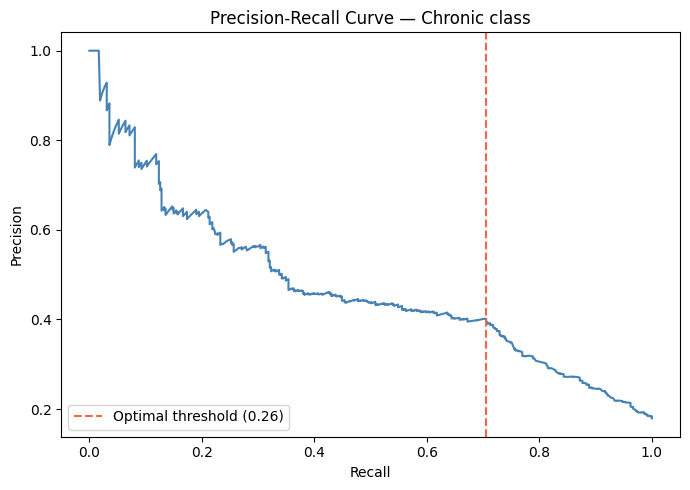

In [7]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-9)
best_thresh = thresholds[f1_scores[:-1].argmax()]

print(f"Default threshold (0.50)  → F1: {f1_score(y_test, y_pred):.4f}  Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}) → F1: {f1_scores[:-1].max():.4f}  Recall: {recall_curve[f1_scores[:-1].argmax()]:.4f}")

y_pred_opt = (y_pred_proba >= best_thresh).astype(int)
print()
print(classification_report(y_test, y_pred_opt, target_names=['Non-Chronic', 'Chronic']))

# Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, color='steelblue')
plt.axvline(recall_curve[f1_scores[:-1].argmax()], color='tomato', linestyle='--',
            label=f'Optimal threshold ({best_thresh:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Chronic class')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Confusion matrix

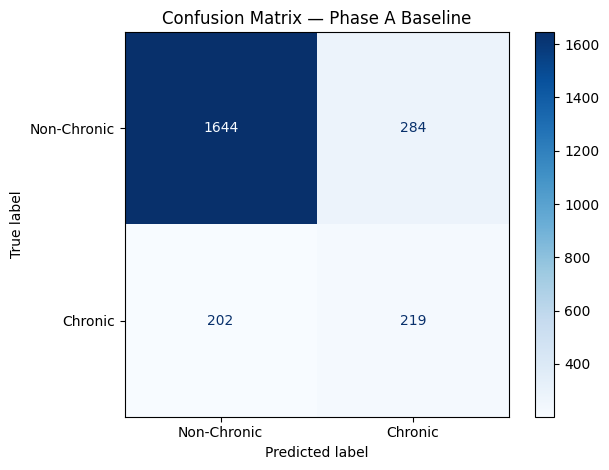

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Chronic', 'Chronic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Phase A Baseline')
plt.tight_layout()
plt.show()

## 7. Calibration curve

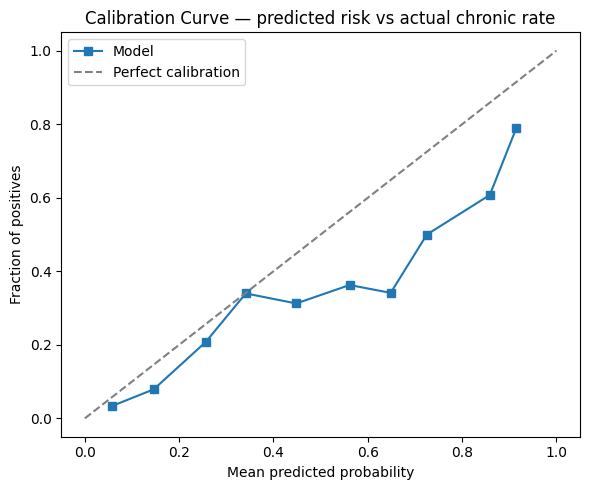

In [9]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, 's-', label='Model')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve — predicted risk vs actual chronic rate')
plt.legend()
plt.tight_layout()
plt.show()

## 8. SHAP feature importance

/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


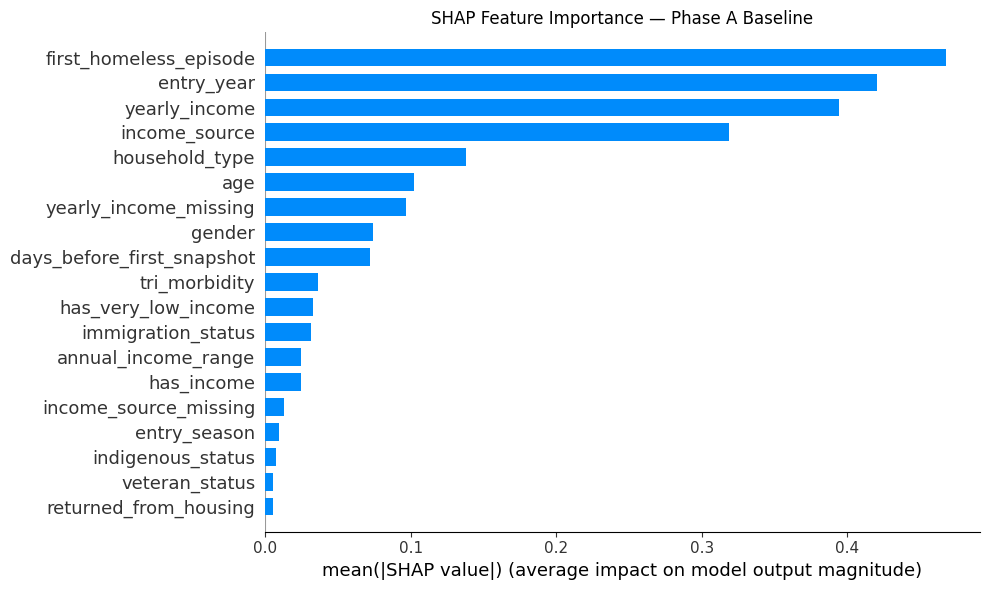

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification LightGBM returns list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_test, plot_type='bar', max_display=20,
                  show=False, plot_size=(10, 6))
plt.title('SHAP Feature Importance — Phase A Baseline')
plt.tight_layout()
plt.show()

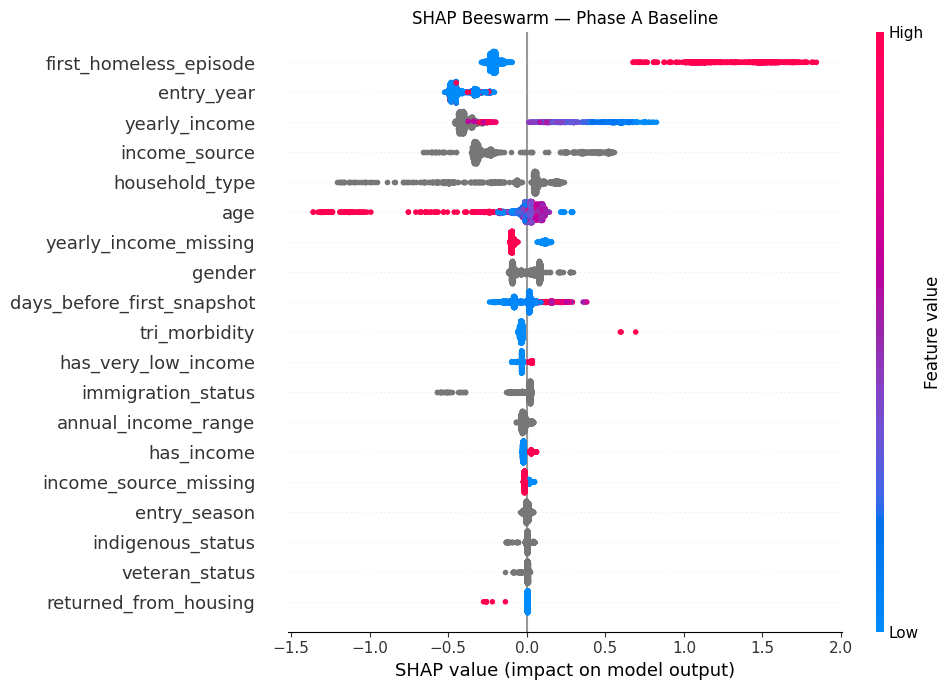

In [11]:
# Beeswarm plot — shows direction and magnitude of each feature
shap.summary_plot(sv, X_test, max_display=20, show=False, plot_size=(10, 7))
plt.title('SHAP Beeswarm — Phase A Baseline')
plt.tight_layout()
plt.show()

## 9. Save model artifact

In [12]:
today = date.today().strftime('%Y%m%d')
model_path = f'../models/phase_a_baseline_{today}.pkl'
joblib.dump({'model': model, 'feature_cols': list(X_train.columns), 'cat_features': cat_cols_in_X}, model_path)
print(f"Model saved to: {model_path}")

Model saved to: ../models/phase_a_baseline_20260414.pkl


## 10. Test predictions

In [13]:
THRESHOLD = 0.20

# --- Test 1: First client in test set ---
print("=" * 50)
print("TEST 1 — First client in test set")
print("=" * 50)
client = X_test.iloc[0:1]
proba = model.predict_proba(client)[0][1]
actual = y_test.iloc[0]

print(client.T.to_string())
print(f"\nRisk score  : {proba:.1%}")
print(f"Prediction  : {'CHRONIC RISK' if proba >= THRESHOLD else 'LOW RISK'}")
print(f"Actual outcome: {'Chronic' if actual == 1 else 'Non-Chronic'}")
print(f"Model correct : {'YES' if (proba >= THRESHOLD) == actual else 'NO'}")

TEST 1 — First client in test set
                                              0
entry_year                                 2024
entry_season                               Fall
days_before_first_snapshot                  270
age                                          39
gender                                     Male
indigenous_status                Non-Indigenous
veteran_status                    Not a Veteran
immigration_status             Canadian Citizen
household_type                           Single
has_income                                    1
income_source                Ontario Works (OW)
income_source_missing                         0
yearly_income                            8400.0
yearly_income_missing                         0
annual_income_range         Very Low (0-19,999)
has_very_low_income                           1
tri_morbidity                                 0
returned_from_housing                         0
first_homeless_episode                        1

Risk 

In [14]:
# --- Test 2: Specific client by ID ---
print("=" * 50)
print("TEST 2 — Client A356G74")
print("=" * 50)

client_id = 'A356G74'
client_row = training_df[training_df['Dummy Client ID'] == client_id]

if len(client_row) == 0:
    print(f"Client {client_id} not found in dataset")
else:
    X_client, _ = get_X_y(client_row)
    proba = model.predict_proba(X_client)[0][1]
    actual = client_row['became_chronic'].values[0]

    print(X_client.T.to_string())
    print(f"\nRisk score    : {proba:.1%}")
    print(f"Prediction    : {'CHRONIC RISK' if proba >= THRESHOLD else 'LOW RISK'}")
    print(f"Actual outcome: {'Chronic' if actual == 1 else 'Non-Chronic'}")
    print(f"Model correct : {'YES' if (proba >= THRESHOLD) == actual else 'NO'}")

TEST 2 — Client A356G74
                                             98
entry_year                                 2019
entry_season                             Summer
days_before_first_snapshot                 1397
age                                          33
gender                                     Male
indigenous_status                       Unknown
veteran_status                    Not a Veteran
immigration_status             Canadian Citizen
household_type                           Single
has_income                                    1
income_source                Ontario Works (OW)
income_source_missing                         0
yearly_income                            4116.0
yearly_income_missing                         0
annual_income_range         Very Low (0-19,999)
has_very_low_income                           1
tri_morbidity                                 0
returned_from_housing                         0
first_homeless_episode                        0

Risk score    :

In [15]:
# --- Test 3: Hard cases — chronic clients the model almost missed ---
print("=" * 50)
print("TEST 3 — Chronic clients with low predicted risk")
print("=" * 50)

borderline = X_test.copy()
borderline['proba'] = y_pred_proba
borderline['actual'] = y_test.values

hard_cases = borderline[(borderline['proba'] < 0.35) & (borderline['actual'] == 1)].sort_values('proba')
print(f"Chronic clients with predicted risk < 35%: {len(hard_cases)}")
print()
print(hard_cases[['age', 'gender', 'indigenous_status', 'household_type',
                   'tri_morbidity', 'has_income', 'first_homeless_episode', 'proba']].head(10).to_string())

TEST 3 — Chronic clients with low predicted risk
Chronic clients with predicted risk < 35%: 173

      age  gender indigenous_status household_type  tri_morbidity  has_income  first_homeless_episode     proba
5212   81  Female    Non-Indigenous         Single              0           0                       0  0.048189
3413   79  Female    Non-Indigenous         Single              0           0                       0  0.067171
6060   75  Female    Non-Indigenous         Single              0           0                       0  0.069088
8773   73    Male    Non-Indigenous         Single              0           0                       0  0.095620
5656   60  Female    Non-Indigenous         Single              0           0                       0  0.109912
927    18  Female    Non-Indigenous    Family Head              0           0                       0  0.112926
7097   25  Female    Non-Indigenous    Family Head              0           0                       0  0.116772
6700   